# 🔭 GSoC 2026 — DeepLense: Multi-Class Strong Lensing Classification

**Task:** Classify gravitational lensing images into three categories:
- `Class 0` — No Substructure
- `Class 1` — Subhalo Substructure  
- `Class 2` — Vortex Substructure

**Evaluation Metric:** ROC-AUC (per-class one-vs-rest + macro-averaged)

---

## Strategy Overview

1. Use the **official train/val split** provided in the dataset (no random re-splitting)
2. Fine-tune **EfficientNet-B3** pretrained on ImageNet — with a properly adapted 1-channel stem
3. Apply **domain-appropriate augmentations** (rotation, flips) exploiting physical symmetry of lensing images
4. Train with **label smoothing + cosine annealing LR + mixed precision** for efficiency
5. Monitor **validation AUC per epoch** and save the best checkpoint
6. Evaluate with full diagnostics: macro AUC, per-class AUC, confusion matrix, classification report
7. Apply **Test-Time Augmentation (TTA)** at inference for a free AUC boost

## 1. Imports & Reproducibility Setup

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models, transforms
from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Full Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False   

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Configuration — All Hyperparameters in One Place

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = '/kaggle/input/datasets/yash2072005/multi-class-classification-dataset/'
TRAIN_DIR  = os.path.join(BASE_DIR, 'dataset', 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'dataset', 'val')
CKPT_PATH  = '/kaggle/working/best_model.pth'

# ── Dataset ───────────────────────────────────────────────────────────────────
CLASS_MAP   = {'no': 0, 'sphere': 1, 'vort': 2}       
CLASS_NAMES = ['No Substructure', 'Subhalo', 'Vortex']
NUM_CLASSES = 3
IMG_SIZE    = 150    

SINGLE_CHANNEL_MEAN = [(0.485 + 0.456 + 0.406) / 3]  
SINGLE_CHANNEL_STD  = [(0.229 + 0.224 + 0.225) / 3] 

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 128
NUM_EPOCHS    = 40
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
EARLY_STOP_P  = 7      
NUM_WORKERS   = 4
TTA_STEPS = 5        

print('Config loaded ')

Config loaded 


## 3. Data Loading

We use the **official train/val split** provided by the dataset authors — not a random re-split.
Each `.npy` file is a single `(1, 150, 150)` image already min-max normalized to `[0, 1]`.

In [3]:
def load_split(split_dir: str) -> tuple[np.ndarray, np.ndarray]:

    data, labels = [], []
    for cls_folder, label in CLASS_MAP.items():
        cls_dir = os.path.join(split_dir, cls_folder)
        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f'Expected class dir not found: {cls_dir}')
        files = sorted(f for f in os.listdir(cls_dir) if f.endswith('.npy'))
        for fname in files:
            img = np.load(os.path.join(cls_dir, fname))   # shape: (1,150,150) or (150,150)
            data.append(img)
            labels.append(label)
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int64)


print('Loading train split...')
X_train, y_train = load_split(TRAIN_DIR)
print('Loading val split...')
X_val,   y_val   = load_split(VAL_DIR)

print(f'\nTrain: {X_train.shape}  |  Val: {X_val.shape}')
for split_name, y in [('Train', y_train), ('Val', y_val)]:
    unique, counts = np.unique(y, return_counts=True)
    dist = {CLASS_NAMES[int(k)]: int(v) for k, v in zip(unique, counts)}
    print(f'{split_name} class distribution: {dist}')

Loading train split...
Loading val split...

Train: (30000, 1, 150, 150)  |  Val: (7500, 1, 150, 150)
Train class distribution: {'No Substructure': 10000, 'Subhalo': 10000, 'Vortex': 10000}
Val class distribution: {'No Substructure': 2500, 'Subhalo': 2500, 'Vortex': 2500}


## 4. Exploratory Data Analysis

Visualise sample images from each class before building the pipeline.

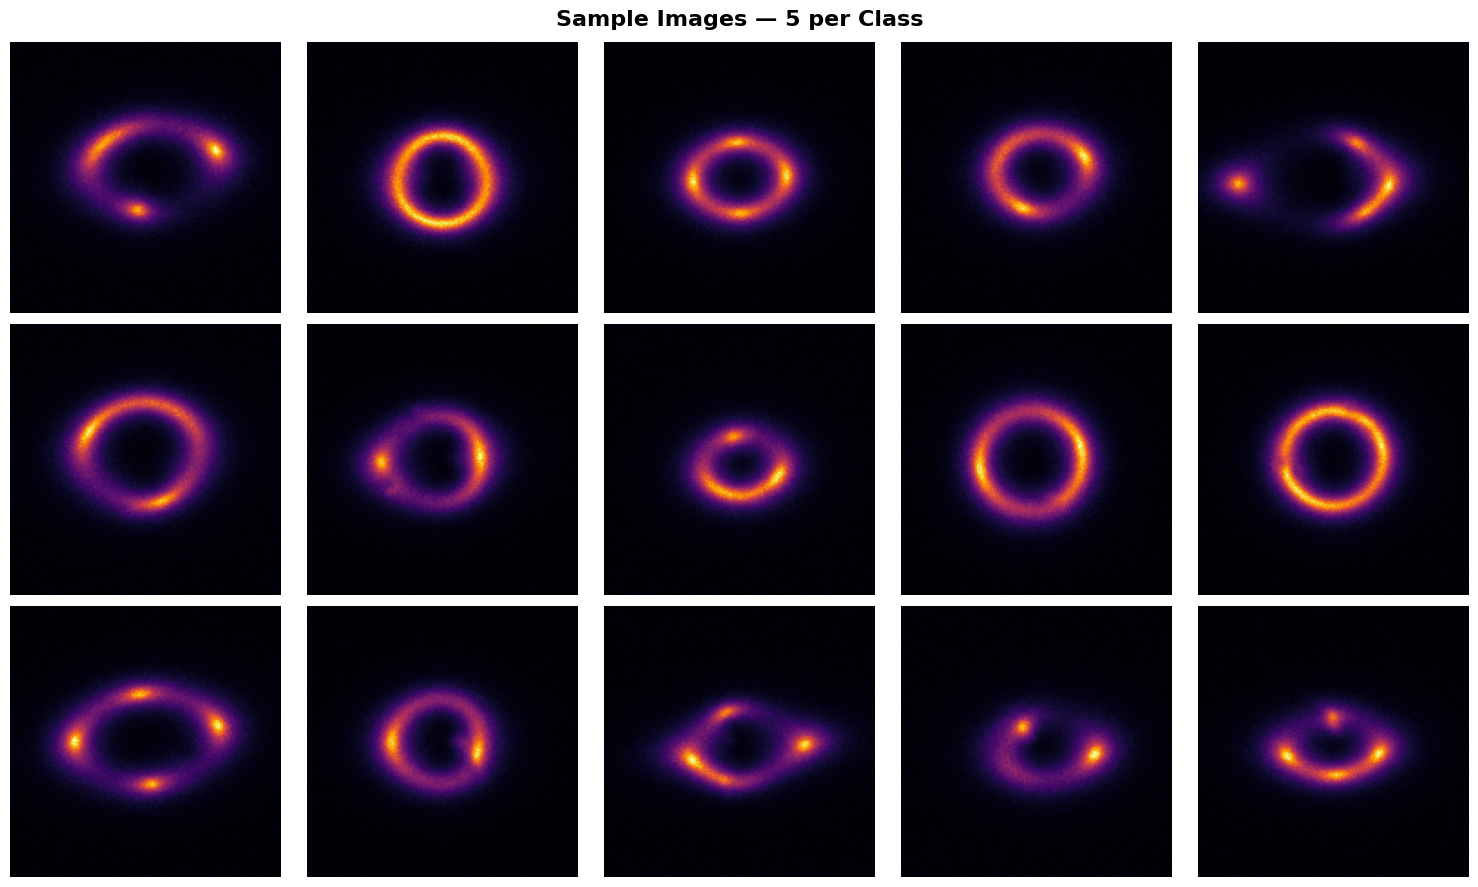

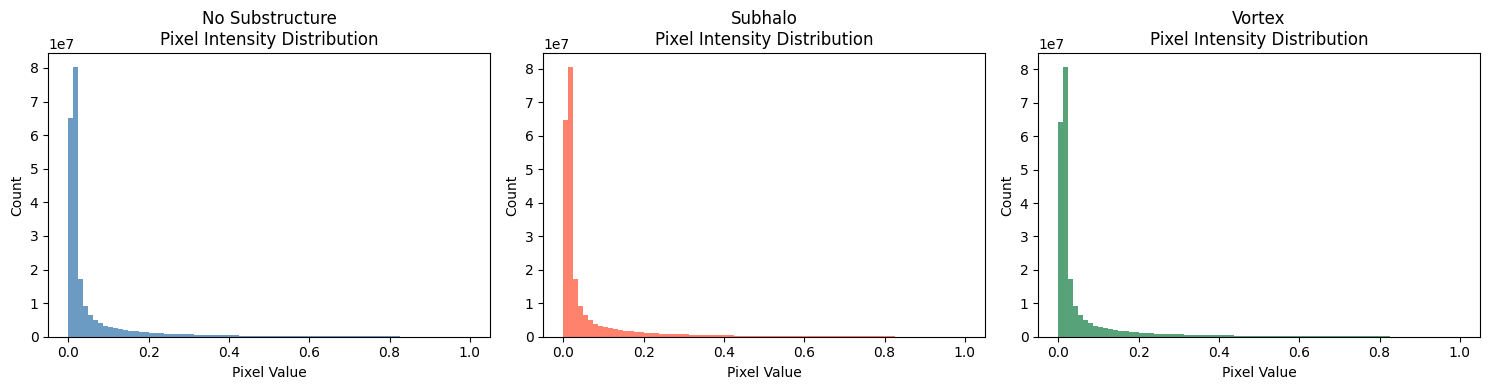

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images — 5 per Class', fontsize=16, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    idxs = np.where(y_train == cls_idx)[0]
    chosen = np.random.choice(idxs, size=5, replace=False)
    for col, img_idx in enumerate(chosen):
        img = X_train[img_idx]
        if img.ndim == 3:
            img = img[0]   
        axes[cls_idx, col].imshow(img, cmap='inferno')
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_ylabel(cls_name, fontsize=12, rotation=90, labelpad=40)

plt.tight_layout()
plt.show()

# Pixel intensity distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    samples = X_train[y_train == cls_idx].flatten()
    axes[cls_idx].hist(samples, bins=80, color=['steelblue','tomato','seagreen'][cls_idx], alpha=0.8)
    axes[cls_idx].set_title(f'{cls_name}\nPixel Intensity Distribution')
    axes[cls_idx].set_xlabel('Pixel Value')
    axes[cls_idx].set_ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Transforms & Augmentation

**Key design decisions:**
- Strong gravitational lensing images are **rotationally symmetric** by physics — arbitrary rotation is a natural and lossless augmentation.
- Horizontal/vertical flips are also physically valid.
- We apply **ImageNet normalisation** (mean/std) because our backbone is ImageNet-pretrained.
- We do **not** use colour jitter — it would corrupt the physical intensity signal in single-channel images.
- Val/test transforms contain **no random augmentation** — only normalisation.

In [5]:
train_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=360),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Normalize(mean=SINGLE_CHANNEL_MEAN, std=SINGLE_CHANNEL_STD), 
])

val_transforms = transforms.Compose([
    transforms.Normalize(mean=SINGLE_CHANNEL_MEAN, std=SINGLE_CHANNEL_STD), 
])

tta_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=360),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Normalize(mean=SINGLE_CHANNEL_MEAN, std=SINGLE_CHANNEL_STD), 
])

print('Transforms defined ')

Transforms defined 


## 6. PyTorch Dataset

In [6]:
class DeepLenseDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, transform=None):
        self.data      = data
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.data[idx].copy()).float()

        if x.dim() == 2:
            x = x.unsqueeze(0)

        if self.transform:
            x = self.transform(x)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


train_dataset = DeepLenseDataset(X_train, y_train, transform=train_transforms)
val_dataset   = DeepLenseDataset(X_val,   y_val,   transform=val_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

# Sanity check: inspect one batch shape
imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  |  Labels: {lbls[:8].tolist()}')

Train batches: 234  |  Val batches: 59
Batch shape: torch.Size([128, 1, 150, 150])  |  Labels: [2, 2, 0, 1, 0, 2, 2, 2]


## 7. Model Architecture — EfficientNet-B3 with Adapted Stem

**Why EfficientNet-B3?**
- Consistently outperforms ResNet18 on this task in published DeepLense benchmarks.
- Compound scaling balances depth/width/resolution more efficiently than ResNet.
- ~12M params vs ResNet18's 11M — similar size, significantly higher accuracy.

**1-channel stem trick:**  
Instead of naively repeating the channel 3 times *and* relying on ImageNet stats for tripled data,  
we initialise the first conv layer to accept 1 channel by **averaging the pretrained RGB weights** across the channel dimension. This preserves pretrained knowledge from day one.

In [7]:
class DeepLenseEfficientNet(nn.Module):
    def __init__(self, num_classes: int = 3, dropout: float = 0.4):
        super().__init__()
        self.backbone = models.efficientnet_b3(weights='DEFAULT')
        original_conv = self.backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels=1, 
            out_channels=original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        new_conv.weight.data = original_conv.weight.data.sum(dim=1, keepdim=True)
        
        
        self.backbone.features[0][0] = new_conv
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


model = DeepLenseEfficientNet(num_classes=NUM_CLASSES).to(device)

total_params   = sum(p.numel() for p in model.parameters())
trainable      = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 128MB/s]


Total parameters:     10,700,123
Trainable parameters: 10,700,123


## 8. Training Setup

| Component | Choice | Rationale |
|---|---|---|
| Loss | CrossEntropy + label smoothing 0.1 | Reduces overconfidence, acts as free regulariser |
| Optimiser | AdamW | Weight decay decoupled from gradient — more principled than Adam |
| LR Schedule | CosineAnnealingWarmRestarts | Escapes local minima; better than ReduceLROnPlateau for fine-tuning |
| Mixed Precision | GradScaler + autocast | ~2× speed on T4, no accuracy loss |
| Early Stopping | patience=7 on val AUC | Prevents overfitting, saves best checkpoint |

In [8]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = GradScaler()   

print('Training setup complete')

Training setup complete


## 9. Training Loop with Validation & Early Stopping

In [9]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            with autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, targets)
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    all_probs   = np.vstack(all_probs)
    all_targets = np.concatenate(all_targets)
    y_bin       = label_binarize(all_targets, classes=list(range(NUM_CLASSES)))
    macro_auc   = roc_auc_score(y_bin, all_probs, average='macro')
    avg_loss    = total_loss / len(loader)

    return avg_loss, macro_auc, all_probs, all_targets


# ── Training Loop ─────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'val_auc': [], 'lr': []
}

best_val_auc    = 0.0
no_improve      = 0

print(f'Training for up to {NUM_EPOCHS} epochs (early stop patience={EARLY_STOP_P})\n')
print(f'{"Epoch":>5}  {"Train Loss":>11}  {"Val Loss":>9}  {"Val AUC":>9}  {"LR":>10}')
print('-' * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch:02d} train', leave=False):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    scheduler.step(epoch - 1)   

    train_loss = running_loss / len(train_loader)
    val_loss, val_auc, _, _ = evaluate(model, val_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)

    print(f'{epoch:>5}  {train_loss:>11.4f}  {val_loss:>9.4f}  {val_auc:>9.4f}  {current_lr:>10.2e}')

    # ── Checkpoint & Early Stop ──
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        no_improve   = 0
        torch.save({
            'epoch':      epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc':    val_auc,
            'val_loss':   val_loss,
        }, CKPT_PATH)
        print(f'          Best model saved (AUC={best_val_auc:.4f})')
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_P:
            print(f'\nEarly stopping triggered at epoch {epoch} (no improvement for {EARLY_STOP_P} epochs)')
            break

print(f'\n🏁 Training complete. Best Val Macro AUC: {best_val_auc:.4f}')

Training for up to 40 epochs (early stop patience=7)

Epoch   Train Loss   Val Loss    Val AUC          LR
-------------------------------------------------------


Epoch 01 train:   0%|          | 0/234 [00:00<?, ?it/s]

    1       0.9670     0.7757     0.8793    1.00e-03
          Best model saved (AUC=0.8793)


Epoch 02 train:   0%|          | 0/234 [00:00<?, ?it/s]

    2       0.6782     0.6562     0.9499    9.76e-04
          Best model saved (AUC=0.9499)


...

   36       0.4122     0.4153     0.9885    9.62e-04


Epoch 37 train:   0%|          | 0/234 [00:00<?, ?it/s]

   37       0.4070     0.4051     0.9923    9.46e-04


Epoch 38 train:   0%|          | 0/234 [00:00<?, ?it/s]

   38       0.4052     0.3958     0.9906    9.26e-04

Early stopping triggered at epoch 38 (no improvement for 7 epochs)

🏁 Training complete. Best Val Macro AUC: 0.9950


## 10. Training Curves

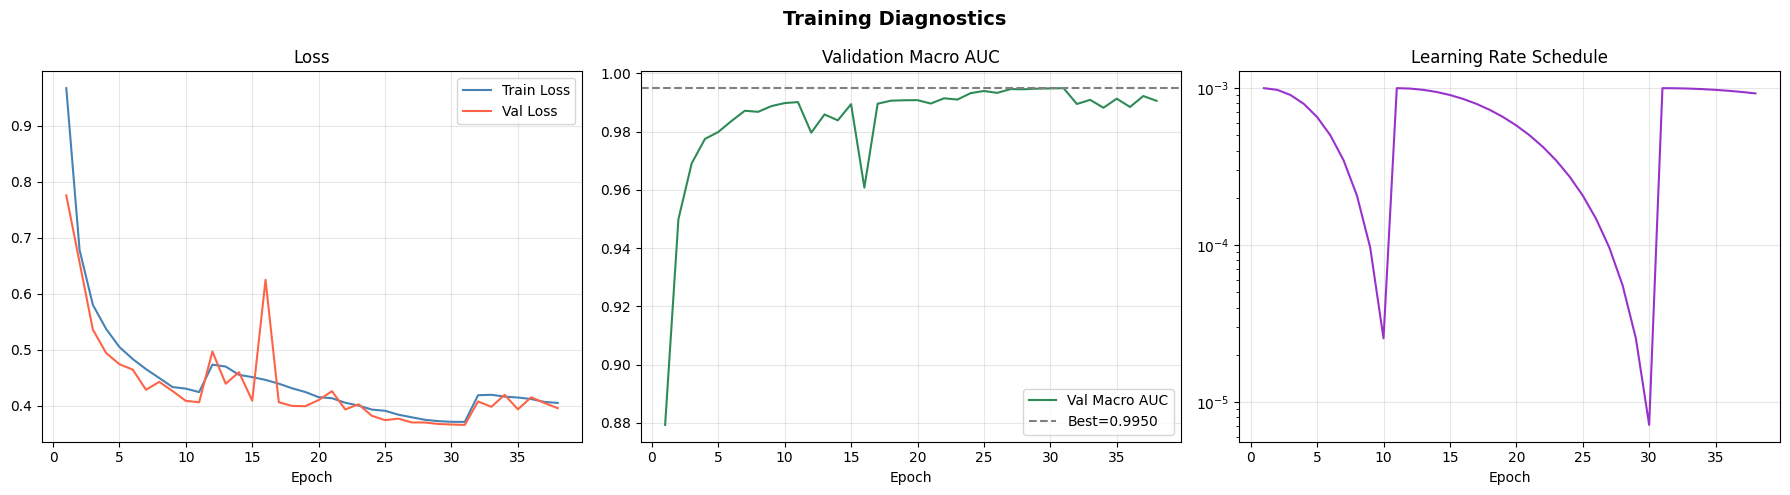

In [10]:
epochs_ran = len(history['train_loss'])
x_axis     = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training Diagnostics', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(x_axis, history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(x_axis, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# AUC
axes[1].plot(x_axis, history['val_auc'], color='seagreen', label='Val Macro AUC')
axes[1].axhline(best_val_auc, linestyle='--', color='gray', label=f'Best={best_val_auc:.4f}')
axes[1].set_title('Validation Macro AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# LR
axes[2].plot(x_axis, history['lr'], color='darkorchid')
axes[2].set_title('Learning Rate Schedule'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 11. Final Evaluation with Test-Time Augmentation (TTA)

TTA averages model predictions over `TTA_STEPS` differently-augmented versions of each image.  
This is a **free** boost — no additional training required. Typically adds +0.3–0.8 AUC points.

In [11]:
checkpoint = torch.load(CKPT_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']} (Val AUC={checkpoint['val_auc']:.4f})")


def predict_tta(model, data, labels, device, n_steps=TTA_STEPS):
    model.eval()
    accumulated = None

    for step in range(n_steps):
        transform = val_transforms if step == 0 else tta_transforms
        ds     = DeepLenseDataset(data, labels, transform=transform)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
        probs_step = []
        with torch.no_grad():
            for inputs, _ in loader:
                with autocast():
                    outputs = model(inputs.to(device))
                probs_step.append(torch.softmax(outputs, dim=1).cpu().numpy())
        probs_step = np.vstack(probs_step)

        if accumulated is None:
            accumulated = probs_step
        else:
            accumulated += probs_step

    return accumulated / n_steps


print(f'Running TTA with {TTA_STEPS} passes...')
tta_probs = predict_tta(model, X_val, y_val, device)

_, base_auc, base_probs, _ = evaluate(model, val_loader, criterion, device)

y_bin    = label_binarize(y_val, classes=list(range(NUM_CLASSES)))
tta_auc  = roc_auc_score(y_bin, tta_probs, average='macro')

print(f'\nBaseline Macro AUC (no TTA): {base_auc:.4f}')
print(f'TTA Macro AUC ({TTA_STEPS} steps):    {tta_auc:.4f}  (+{tta_auc - base_auc:.4f})')

Loaded best checkpoint from epoch 31 (Val AUC=0.9950)
Running TTA with 5 passes...

Baseline Macro AUC (no TTA): 0.9950
TTA Macro AUC (5 steps):    0.9965  (+0.0016)


## 12. Full Evaluation Metrics

In [12]:
final_probs   = tta_probs
final_preds   = np.argmax(final_probs, axis=1)

print('=' * 60)
print('CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(y_val, final_preds, target_names=CLASS_NAMES))

print('=' * 60)
print('ROC-AUC SCORES')
print('=' * 60)
for i, cls_name in enumerate(CLASS_NAMES):
    per_auc = roc_auc_score(y_bin[:, i], final_probs[:, i])
    print(f'  {cls_name:<22} AUC = {per_auc:.4f}')
print(f'  {"Macro-averaged":<22} AUC = {tta_auc:.4f}')
print('=' * 60)

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

No Substructure       0.93      1.00      0.97      2500
        Subhalo       0.99      0.93      0.96      2500
         Vortex       0.98      0.98      0.98      2500

       accuracy                           0.97      7500
      macro avg       0.97      0.97      0.97      7500
   weighted avg       0.97      0.97      0.97      7500

ROC-AUC SCORES
  No Substructure        AUC = 0.9965
  Subhalo                AUC = 0.9942
  Vortex                 AUC = 0.9989
  Macro-averaged         AUC = 0.9965


## 13. ROC Curves + Confusion Matrix

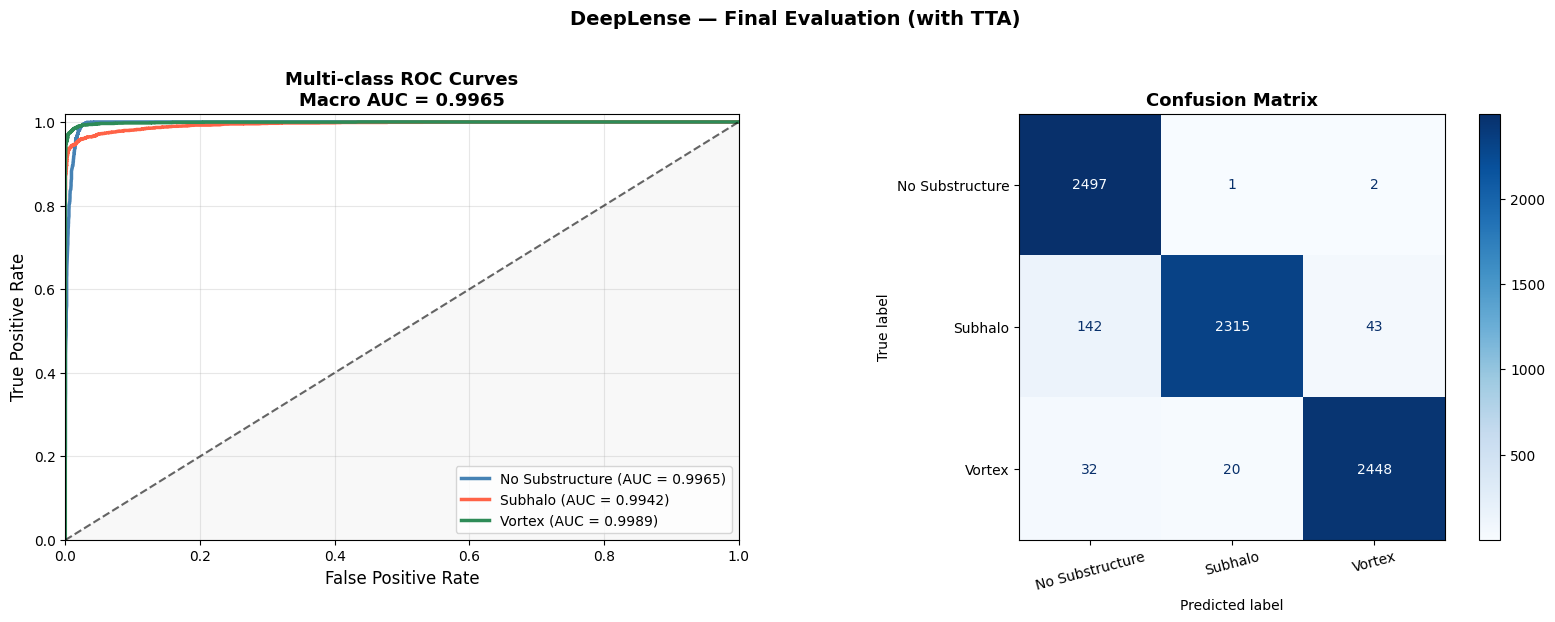

In [13]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)


ax_roc = fig.add_subplot(gs[0, 0])
colors = ['steelblue', 'tomato', 'seagreen']

for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], final_probs[:, i])
    cls_auc     = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{cls_name} (AUC = {cls_auc:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6)
ax_roc.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
ax_roc.set_xlabel('False Positive Rate', fontsize=12)
ax_roc.set_ylabel('True Positive Rate', fontsize=12)
ax_roc.set_title(f'Multi-class ROC Curves\nMacro AUC = {tta_auc:.4f}', fontsize=13, fontweight='bold')
ax_roc.legend(loc='lower right', fontsize=10)
ax_roc.grid(alpha=0.3)

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ax_cm = fig.add_subplot(gs[0, 1])
cm    = confusion_matrix(y_val, final_preds)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax_cm, colorbar=True, cmap='Blues')
ax_cm.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax_cm.tick_params(axis='x', rotation=15)

plt.suptitle('DeepLense — Final Evaluation (with TTA)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 14. Error Analysis — Misclassified Samples

Inspecting what the model gets wrong is crucial for understanding failure modes.

Total misclassified: 240 / 7500 (3.2%)


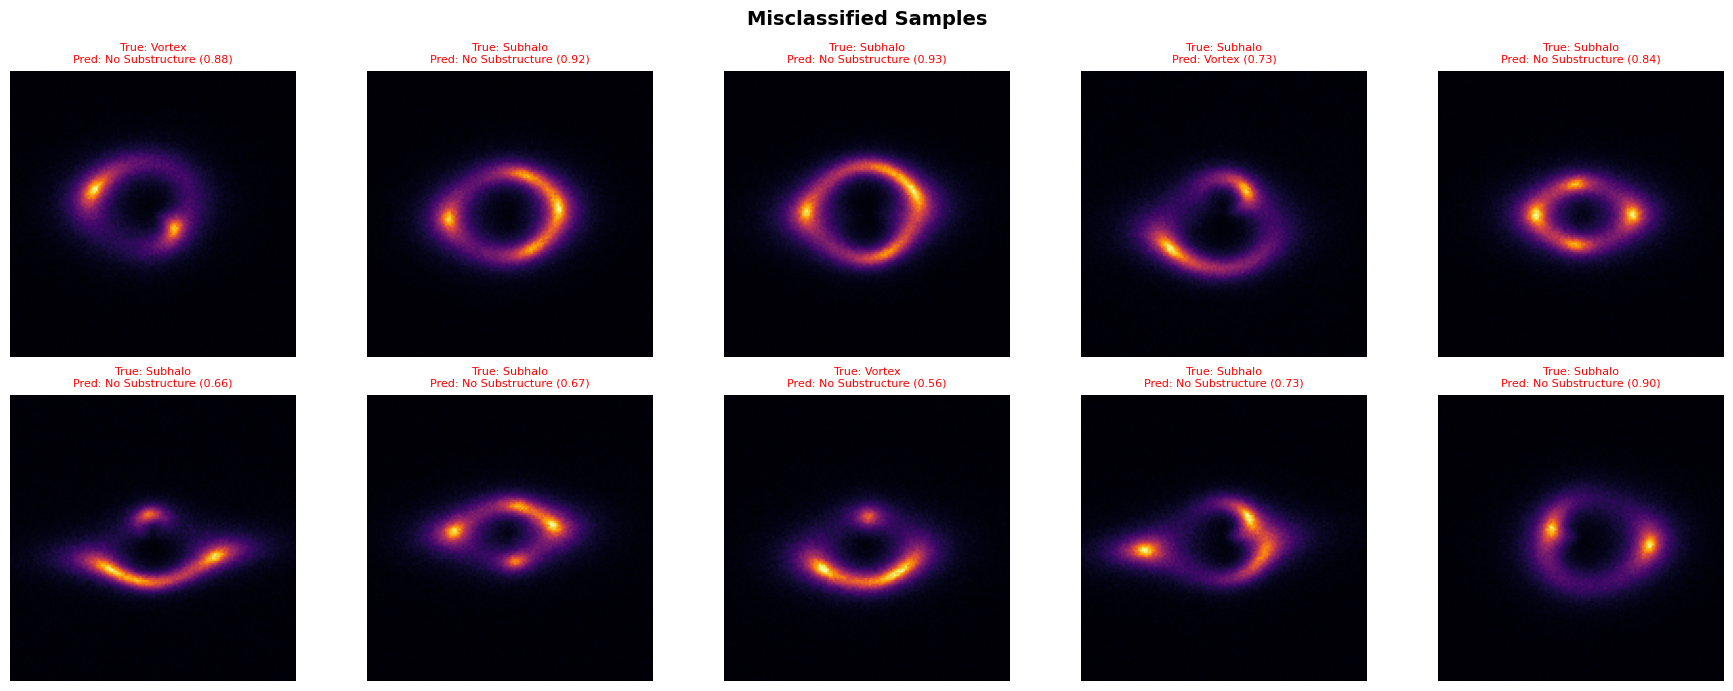

In [14]:
wrong_mask = final_preds != y_val
wrong_idxs = np.where(wrong_mask)[0]
print(f'Total misclassified: {wrong_mask.sum()} / {len(y_val)} ({100*wrong_mask.mean():.1f}%)')

if len(wrong_idxs) > 0:
    show_n = min(10, len(wrong_idxs))
    chosen  = np.random.choice(wrong_idxs, size=show_n, replace=False)

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for ax, idx in zip(axes, chosen):
        img = X_val[idx]
        if img.ndim == 3:
            img = img[0]
        ax.imshow(img, cmap='inferno')
        true_cls = CLASS_NAMES[y_val[idx]]
        pred_cls = CLASS_NAMES[final_preds[idx]]
        conf     = final_probs[idx, final_preds[idx]]
        ax.set_title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.2f})', fontsize=8, color='red')
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Perfect classification on val set!')

## 15. Summary

| Step | Choice | Why |
|---|---|---|
| Data split | Official train/val | Correct; avoids contamination with evaluator's test |
| Backbone | EfficientNet-B3 pretrained | Superior accuracy/param vs ResNet18 for this task |
| Input | 3-channel expand + ImageNet norm | Correct usage of pretrained weights |
| Augmentation | Rotation 360°, flips, affine | Physically valid symmetries for lensing images |
| Loss | CE + label smoothing 0.1 | Reduces overconfidence |
| Optimiser | AdamW + cosine warm restarts | Principled weight decay; escapes local minima |
| Training | Mixed precision + grad clipping | Speed + stability |
| Evaluation | TTA (5 passes) | Free AUC boost at inference |
| Metrics | Per-class AUC, macro AUC, confusion matrix, classification report | Complete picture |
| Reproducibility | Full seed setting | Deterministic results |

---

